# A Support Vector Machine

Лекц 8 дээр бид Дэмжигч вектор машины аргыг үзсэн ба энэхүү лабораторийн ажилаар уг аргыг Python хэл дээр өөрсдийн өгөгдөл ашиглан туршин үзэж стандарт сангын аргатай харьцуулах болно. Илүү ихийг мэдэхийг хүсвэл дараах судалгааны ажилуудыг санал болгож байна. Үүнд:

**Schölkopf & Smola** (2002). Learning with Kernels. Support Vector Machines, Regularization, Optimization, and Beyond.

Мөн түүнчлэн, MIT-ийн SVM-ийн математик суурьтай холбоотой товч танилцуулга байдаг.

https://www.google.de/search?client=ubuntu&channel=fs&q=svm+standford&ie=utf-8&oe=utf-8&gfe_rd=cr&ei=UfDhWM_BMunVXredsIgI#q=support+vector+machine+tutorial&channel=fs&start=10&*


In [ ]:
import numpy as np

X = np.array([
    [-2,4, -1],
    [4, 1, -1],
    [1, 6, -1],
    [2, 4, -1],
    [6, 2, -1],

])

y = np.array([-1,-1,1,1,1])

def svm_sgd(X, Y):

    w = np.zeros(len(X[0]))
    eta = 1
    epochs = 100000


    for epoch in range(1,epochs):
        for i, x in enumerate(X):
            w=0 # svm ангилагчийн хэрэгжүүлэх кодыг бичнэ үү
            # svm ангилагчийн хэрэгжүүлэх кодыг бичнэ үү
            # svm ангилагчийн хэрэгжүүлэх кодыг бичнэ үү

    return w

w = svm_sgd(X,y)
print(w)

0


## Сангуудыг дуудаж оруулах

Эхлээд бид python дээр шугаман алгебр болон тооцооллын үйлдлүүдийг хялбар удирдахын тулд numpy-г ашиглах болно. Суралцах явцыг графикаар дүрсэлж харахын тулд бид matplotlib ашиглана.

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

### Stochastic Gradient Descent

Perceptron-ийн хувьд бид python3 болон numpy ашигладаг. SVM нь Stochastic Gradient Descent алгоритм (SGD) ашиглан суралцах болно. Gradient Descent нь зардлын функцийн градиентийг дагаж функцийг багасгадаг. Дэлгэрэнгүй мэдээллийг үзнэ үү:

Wikipedia - stochastic gradient descent

### Calculating the Error

Урьдчилан таамаглах алдааг тооцоолохын тулд эхлээд svm-ийн зорилгын функцийг тодорхойлох хэрэгтэй.

#### Hinge Loss Function

Үүнийг хийхийн тулд бид алдааны функцийг тодорхойлж, таамаглалын алдааг тооцоолох хэрэгтэй. Бид перцептрондоо Hinge алдагдлыг ашиглах болно:

$$c(x, y, f(x)) = (1 - y * f(x))_+$$

$c$ алдагдлын функц юм, $x$ дээж, $y$ label, $f(x)$ таамагласан label.

Энэ нь дараахь зүйлийг хэлнэ.
$$
c(x, y, f(x))=
\begin{cases}
    0,& \text{if } y*f(x)\geq 1\\
    1-y*f(x),              & \text{else}
\end{cases}
$$

Хэрэв y ба f(x) нь тэмдэгт утгатай бол $(+1,-1)$ бодно:

хэрэв алдаа 0 бол, $y*f(x)$ нэмэх, тус тус хоёр утга ижил тэмдэгтэй байна.

алдаа $1-y*f(x)$ бол $y*f(x)$ сөрөг

#### Objective Function

Бид алдагдлын функцийг тодорхойлсон болохоор svm-ийн зорилгын функцийг тодорхойлж болно.

$$\underset{w}{min}\ \lambda\parallel w\parallel^2 + \ \sum_{i=1}^n\big(1-y_i \langle x_i,w \rangle\big)_+$$

Дээрхээс харвал svm-ийн зорилго нь хоёр нэр томъёоноос бүрдэнэ. Эхний нэр томъёо нь тогтмолжуулагч, хоёр дахь нэр томъёо нь алдагдал юм. Зохицуулагч нь ашгийн хэмжээг нэмэгдүүлэх ба алдагдлын хооронд тэнцвэржүүлдэг. Дэлгэрэнгүй мэдээлэл авахын тулд дээр дурдсан Schölkopf & Smola номын зааварчилгааг харна уу.
#### Derive the Objective Function

Энэ функцийг багасгахын тулд бидэнд энэ функцийн градиент хэрэгтэй.

Бидэнд хоёр нэр томъёо байгаа тул ялгахдаа нийлбэрийн дүрмийг ашиглан тэдгээрийг тусад нь удирдах болно.

$$
\frac{\delta}{\delta w_k} \lambda\parallel w\parallel^2 \ = 2 \lambda w_k
$$

$$
\frac{\delta}{\delta w_k} \big(1-y_i \langle x_i,w \rangle\big)_+ \ = \begin{cases}
    0,& \text{if } y_i \langle x_i,w \rangle\geq 1\\
    -y_ix_{ik},              & \text{else}
\end{cases}
$$

Энэ нь буруу ангилсан дээж байгаа гэсэн үг $x_i$, $y_i  тус  тус  \langle x_i,w \rangle \ < \ 1$, бид хоёр нэр томъёоны градиентыг ашиглан жингийн вектор w-г шинэчилнэ. Хэрэв $y_i \langle x_i,w \rangle \geq 1$. Бид w-г зохицуулагчийн градиентаар шинэчилнэ. Дүгнэж хэлэхэд svm-ийн стохастик градиент нь дараах байдалтай байна.

if $y_i⟨x_i,w⟩ < 1$:
$$
w = w + \eta (y_ix_i - 2\lambda w)
$$
else:
$$
w = w + \eta (-2\lambda w)
$$

### Data Set

Эхлээд бид label-тэй өгөгдлийн багцыг тодорхойлох хэрэгтэй.

In [ ]:
X = np.array([
    [-2, 4],
    [4, 1],
    [1, 6],
    [2, 4],
    [6, 2]
])

y = np.array([-1,-1,1,1,1])

Хялбар байлгахын тулд бид өгөгдлийн багцад bias нэмнэ:

In [ ]:
X = np.array([
    [-2,4,-1],
    [4,1,-1],
    [1, 6, -1],
    [2, 4, -1],
    [6, 2, -1],

])

y = np.array([-1,-1,1,1,1])

Энэхүү жижиг мэдээллийн багц нь $-1$ гэсэн label-тэй хоёр дээж, $+1$ гэсэн label-тэй гурван дээжийг агуулсан. Энэ нь өгөгдлийн багц нь хоёр жишээ анги агуулсан тул бид хоёртын ангиллын асуудалтай байна гэсэн үг юм. Өгөгдлийн багцыг шугаман байдлаар салгах боломжтой графикаар зурцгаая:

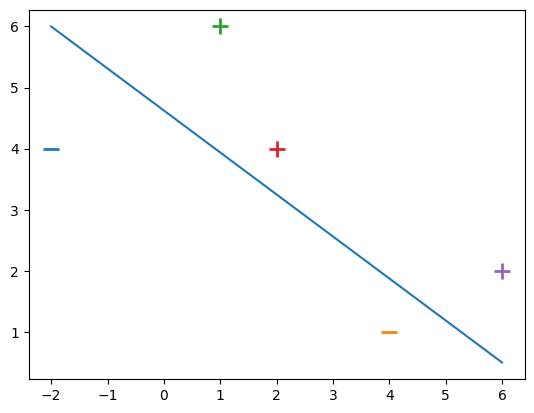

In [ ]:
for d, sample in enumerate(X):
    # Сөрөг дээжийг зурах
    if d < 2:
        plt.scatter(sample[0], sample[1], s=120, marker='_', linewidths=2)
    # Эерэг дээжийг зурах
    else:
        plt.scatter(sample[0], sample[1], s=120, marker='+', linewidths=2)

# Хоёр ангийг тусгаарлаж болох hyperplane зурах.
plt.plot([-2,6],[6,0.5])

## Stochastic Gradient Descent

Эцэст нь бид шинэчлэх дүрмээ ашиглан SGD алгоритмаа кодлох боломжтой боллоо. Перцептронуудын зорилгын функцээс эсрэгээр бид алгоритмдаа тогтмолжуулагчийг ашигладаг. Бидэнд шугаман ялгахад хялбар жижиг өгөгдлийн багц байгаа тул энэ нь үнэндээ шаардлагагүй бөгөөд бидний стохастик градиент өгөгдлийн алгоритм үүнгүйгээр илүү хурдан нэгдэх болно.

Энгийн байлгахын тулд бид дээжийн багц дээр шугаман давталт хийнэ. Том өгөгдлийн багцын хувьд for-loop дахь давталт бүрийн үед түүврийг санамсаргүй байдлаар сонгох нь илүү дээр үр дүн гаргах юм.

In [ ]:
def svm_sgd(X, Y):
    w = np.zeros(len(X[0]))
    eta = 1
    epochs = 100000

    for epoch in range(1,epochs):
        for i, x in enumerate(X):
            w=0 # svm ангилагчийн хэрэгжүүлэх кодыг бичнэ үү
            # svm ангилагчийн хэрэгжүүлэх кодыг бичнэ үү
            # svm ангилагчийн хэрэгжүүлэх кодыг бичнэ үү
            # svm ангилагчийн хэрэгжүүлэх кодыг бичнэ үү
            # svm ангилагчийн хэрэгжүүлэх кодыг бичнэ үү
            # svm ангилагчийн хэрэгжүүлэх кодыг бичнэ үү


    return w

Бид sgd $ 100000$ удаа ажиллуулна. Манай сургалтын параметрийг $1$ гэж тохируулсан. Зохицуулах параметрийн хувьд бид $1/t$-ийг сонгосон тул epoch нэмэгдэх тусам энэ үзүүлэлт буурах болно.

#### Кодын тайлбар Мөр мөрөөр

line <b>2</b>: Перцептроны жингийн векторыг тэгээр эхлүүлнэ<br>
line <b>3</b>: Сурах хурдыг тохируулна уу 1<br>
line <b>4</b>: Epoch тоог тохируулна уу<br>
line <b>6</b>: Бүх өгөгдлийн багцыг n удаа давтана. Тогтворжуулах параметрийг тооцоолохдоо тэг болгон хуваахаас зайлсхийхийн тулд давталт нь $1$-ээс эхэлдэг.<br>
line <b>7</b>: Өгөгдлийн багц дахь дээж бүрийг давтана. <br>
line <b>8</b>: Буруу ангилах нөхцөл $y_i \langle x_i,w \rangle < 1$<br>
line <b>9</b>: Жинг шинэчлэх $w = w + \eta (y_ix_i - 2\lambda w)$ суралцах хурд, $\eta$ болон тогтворжуулагч зэрэг орно $\lambda$<br>
line <b>11</b>: Зөв ангилсан бол жингийн векторыг тогтворжуулагчийн нэр томъёогоор шинэчилнэ $w = w + \eta (-2\lambda w)$.<br>

### SVM-г сурцгаая!

Дараа нь бид сургалтын өгөгдөлд тохирох жингийн векторыг тооцоолохын тулд кодыг ажиллуулж болно. Буруу ангилсан дээж байгаа бол бид буруу ангилсан, зөв ангилсан дээжийн тоог хэвлэх болно.

In [ ]:
def svm_sgd_plot(X, Y):

    w = np.zeros(len(X[0]))
    eta = 1
    epochs = 100000
    errors = []


    for epoch in range(1,epochs):
        error = 0
        for i, x in enumerate(X):
              # svm ангилагчийн хэрэгжүүлэх кодыг бичнэ үү
                error = 1
              # svm ангилагчийн хэрэгжүүлэх кодыг бичнэ үү
        errors.append(error)

    plt.plot(errors, '|')
    plt.ylim(0.5,1.5)
    plt.xlabel('Epoch')
    plt.ylabel('Misclassified')
    plt.show()

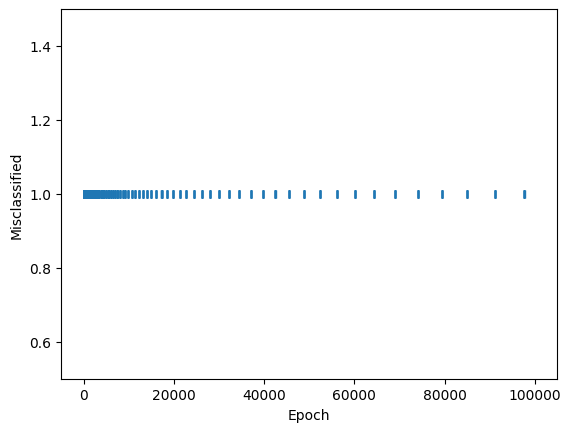

In [ ]:
svm_sgd_plot(X,y)

Дээрх графикаас svm нь олон epoch ажиллах тусам буруу ангиллыг бага гаргадаг болохыг харуулж байна. Манай перцептроноос ялгаатай нь одоогийн дээжийг зөв ангилсан ч svm нь жингийн вектороо зохицуулагчаар шинэчилдэг тул бид байнга тэг алдаа гаргадаггүй. Муу мэт харагдаж байгаа зүйл бол SVM-ийн хүч чадал бөгөөд энэ нь тогтмолжуулагчийг ашиглан хоёр ангийн хоорондох зөрүүг нэмэгдүүлэхийг үргэлж хичээдэг.

Нэгтгэн дүгнэхэд перцептрон ханасан бөгөөд тусгаарлах гипер хавтгайг олоход манай SVM нь эсрэгээрээ хоёр ангийн хоорондох зайг хамгийн их байлгах замаар гипер хавтгайг оновчтой болгохыг үргэлж эрмэлзэнэ.

SVM-ийн жингийн вектор нь 100000 epoch дараах хэвийсэн утгыг агуулсан байна $(1.56,  3.17,  11.12)$.<br>
Бид одоо дараах таамаглах функцийг гаргаж авах боломжтой.


$$
f(x) = \langle x,(1.56,3.17)\rangle - 11.12
$$

Жингийн вектор нь $(1.56,3.17)$ ба bias нь 11.12 гурав дахь бичилт юм.

## Үнэлгээ

Перцептрон зөв сурсан эсэхийг шалгахын тулд өгөгдлийн цуглуулгад байгаа дээжийг гараар ангилж үзье.

Эхний дээж $(-2, 4)$, сөрөг байх ёстой:

$$-2*1,56+4*3,17 - 11,12 = sign(-1,56) = -1$$

Хоёр дахь дээж $(4, 1)$, сөрөг байх ёстой:

$$4*1,56+1*3,17 - 11,12 = sign(-1,71) = -1$$

Гурав дахь жишээ $(1, 6)$, эерэг байх ёстой:

$$1*1,56+6*3,17-11,12 = sign(9,46) = +1$$

Дөрөв дэх жишээ $(2, 4)$, эерэг байх ёстой:

$$2*1,56+4*3,17 - 11,12 = sign(4,68) = +1$$

Тав дахь дээж $(6, 2)$, эерэг байх ёстой:

$$6*1,56+2*3,17 - 11,12 = sign(4,58) = +1$$

Бидний ангилаг сургалтанд ашиглагдаагүй өгөгдлийг хэр сайн нэгтгэж байгааг шалгахын тулд одоо хоёр туршилтын дээжийг тодорхойлъё.

Эхний туршилтын дээж $(2, 2)$, сөрөг байх ёстой:

$$2*1,56+2*3,17 - 11,12 = sign(-1,66) = -1$$

Хоёр дахь туршилтын дээж $(4, 3)$, эерэг байх ёстой:

$$4*1,56+3*3,17 - 11,12 = sign(4,63) = +1$$

Хоёр туршилтын дээжийг зөв ангилсан. Үүнийг геометрийн хувьд шалгахын тулд туршилтын дээж, гиперплан дээр дээжүүдийг хамтад нь зурж үзье.

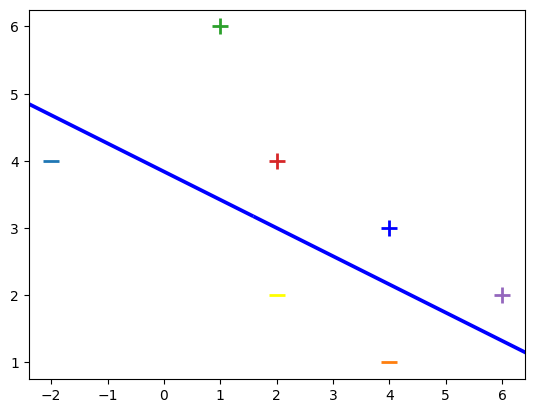

In [ ]:
w = svm_sgd(X, y)
for d, sample in enumerate(X):
    # Сөрөг дээжийг зурах
    if d < 2:
        plt.scatter(sample[0], sample[1], s=120, marker='_', linewidths=2)
    # Эерэг дээжийг зурах
    else:
        plt.scatter(sample[0], sample[1], s=120, marker='+', linewidths=2)

# Туршилтын дээжийг нэмнэх

plt.scatter(2,2, s=120, marker='_', linewidths=2, color='yellow')
plt.scatter(4,3, s=120, marker='+', linewidths=2, color='blue')

# svm_sgd()-ээр тооцоолсон гипер хавтгайг дүрслэх
x2=[w[0],w[1],-w[1],w[0]]
x3=[w[0],w[1],w[1],-w[0]]

x2x3 =np.array([x2,x3])
X,Y,U,V = zip(*x2x3)
ax = plt.gca()
ax.quiver(X,Y,U,V,scale=1, color='blue')


In [ ]:
1/np.linalg.norm(w,2)

0.08567810847428549

# Даалгавар 1: Кодын хэсгийг нөхөх

# SVM Kernel

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as pltcolors
from sklearn import linear_model, svm, discriminant_analysis, metrics
from scipy import optimize
import seaborn as sns

In [ ]:
def plotLine(ax, xRange, w, x0, label, color='grey', linestyle='-', alpha=1.):
    """ Plot a (separating) line given the normal vector (weights) and point of intercept """
    if type(x0) == int or type(x0) == float or type(x0) == np.float64:
        x0 = [0, -x0 / w[1]]
    yy = -(w[0] / w[1]) * (xRange - x0[0]) + x0[1]
    ax.plot(xRange, yy, color=color, label=label, linestyle=linestyle)

def plotSvm(X, y, support=None, w=None, intercept=0., label='Data', separatorLabel='Separator',
            ax=None, bound=[[-1., 1.], [-1., 1.]]):
    """ Plot the SVM separation, and margin """
    if ax is None:
        fig, ax = plt.subplots(1)

    im = ax.scatter(X[:,0], X[:,1], c=y, cmap=cmap, alpha=0.5, label=label)
    if support is not None:
        ax.scatter(support[:,0], support[:,1], label='Support', s=80, facecolors='none',
                   edgecolors='y', color='y')
        print("Number of support vectors = %d" % (len(support)))
    if w is not None:
        xx = np.array(bound[0])
        plotLine(ax, xx, w, intercept, separatorLabel)
        # Захын зайг дүрслэх
        if support is not None:
            signedDist = np.matmul(support, w)
            margin = np.max(signedDist) - np.min(signedDist) * np.sqrt(np.dot(w, w))
            supportMaxNeg = support[np.argmin(signedDist)]
            plotLine(ax, xx, w, supportMaxNeg, 'Margin -', linestyle='-.', alpha=0.8)
            supportMaxPos = support[np.argmax(signedDist)]
            plotLine(ax, xx, w, supportMaxPos, 'Margin +', linestyle='--', alpha=0.8)
            ax.set_title('Margin = %.3f' % (margin))
    ax.legend(loc='upper left')
    ax.grid()
    ax.set_xlim(bound[0])
    ax.set_ylim(bound[1])
    cb = plt.colorbar(im, ax=ax)
    loc = np.arange(-1,1,1)
    cb.set_ticks(loc)
    cb.set_ticklabels(['-1','1'])

In [ ]:
def plotHeatMap(X, classes, title=None, fmt='.2g', ax=None, xlabel=None, ylabel=None):
    """ Fix heatmap plot from Seaborn with pyplot 3.1.0, 3.1.1
        https://stackoverflow.com/questions/56942670/matplotlib-seaborn-first-and-last-row-cut-in-half-of-heatmap-plot
    """
    ax = sns.heatmap(X, xticklabels=classes, yticklabels=classes, annot=True, \
                     fmt=fmt, cmap=plt.cm.Blues, ax=ax)
    bottom, top = ax.get_ylim()
    ax.set_ylim(bottom + 0.5, top - 0.5)
    if title:
        ax.set_title(title)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)

def plotConfusionMatrix(yTrue, yEst, classes, title=None, fmt='.2g', ax=None):
    plotHeatMap(metrics.confusion_matrix(yTrue, yEst), classes, title, fmt, ax, xlabel='Estimations', \
                ylabel='True values');

In [ ]:
def generateBatchXor(n, mu=0.5, sigma=0.5):
    """ Four gaussian clouds in a Xor fashion """
    X = np.random.normal(mu, sigma, (n, 2))
    yB0 = np.random.uniform(0, 1, n) > 0.5
    yB1 = np.random.uniform(0, 1, n) > 0.5
    y0 = 2. * yB0 - 1
    y1 = 2. * yB1 - 1
    X[:,0] *= y0
    X[:,1] *= y1
    X -= X.mean(axis=0)
    return X, y0*y1

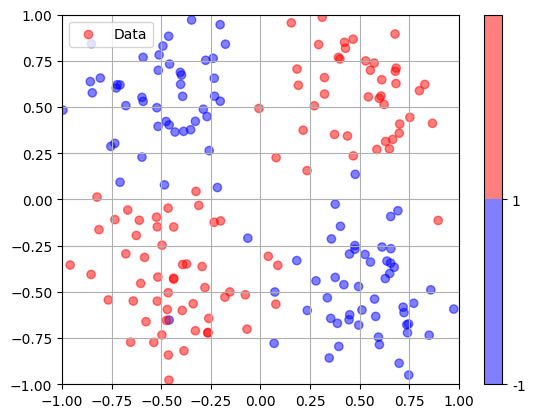

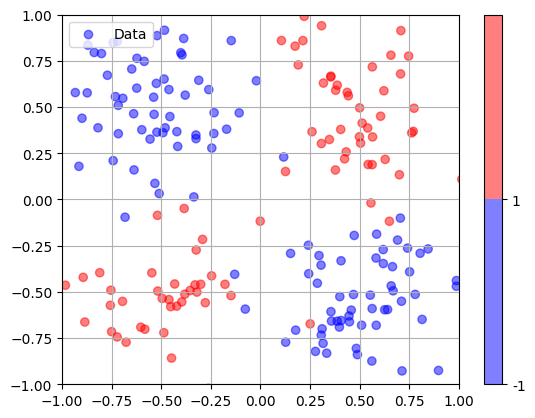

In [ ]:
colors = ['blue','red']
cmap = pltcolors.ListedColormap(colors)
nFeatures = 2
N = 100
xTrain, yTrain = generateBatchXor(2*N, sigma=0.25)
plotSvm(xTrain, yTrain)
xTest, yTest = generateBatchXor(2*N, sigma=0.25)
plotSvm(xTest, yTest)

## Kernel trick танилцуулга

Регресс гэх мэт шугаман тусгаарлагчийг ашиглах үед шугаман бус функцийг шийдвэрлэх уламжлалт арга бол анхны шинж чанаруудын зэрэгт болон үржвэрүүдийг ашиглан функцын орон зайг өргөжүүлэх явдал юм.

Шугаман арганд хязгаарлалт бий. Жишээлбэл, XOR асуудлыг зөв шийдвэрийн муж гаргаагүй байна.

SVM нь "Kernel trick" гэгддэг шинэ аргыг ашигласан.

$h(x)$ функцийг ашиглан $x$-д хувиргалтыг хэрэгжүүлцгээе.

Лагранж (Вольф) давхар (хос) асуудал дараах байдалтай байна.
$$\begin{align}
\mathcal{L}_d (\alpha)
&= \sum_{i=0}^n \alpha_i - \frac 12 \sum_{i=0}^n \sum_{k=0}^n \alpha_i \alpha_k y_i y_k h(x_i)^T h(x_k) \\
&= \sum_{i=0}^n \alpha_i - \frac 12 \sum_{i=0}^n \sum_{k=0}^n \alpha_i \alpha_k \langle y_i h(x_i), y_k  h(x_k) \rangle \\
\end{align}$$

__Subject to $\forall i\in 1..n$:__
- $0 \le \alpha_i \le C$
- $\sum_{i=0}^n \alpha_i y_i = 0$

$ w = \sum_{i=0}^n \alpha_i y_i h(x_i)$ тул таамаглах функц байна:
$$ f(x) = sign(w^T h(x) + b) = sign \left(\sum_{i=0}^n \alpha_i y_i \langle h(x_i), h(x) \rangle \right) $$

Энэ таамаглалыг дэмжих вектор болох $\alpha_i > 0$-д тооцоолох шаардлагатай.

Тохиромжтой болон таамаглал хоёулаа Kernel функц гэгддэг $K(x, x') = \langle h(x), h(x') \rangle$ дотоод бүтээгдэхүүн дээр суурилдаг. Энэ функц нь тэгш хэмтэй, хагас тодорхой байна.

Gaussian Radial Basis Function (RBF) : $K(x, x') = exp(- \gamma \Vert x - x' \Vert^2 )$

In [ ]:
class KernelSvmClassifier:

    def __init__(self, C, kernel):
        self.C = C
        self.kernel = kernel          # <---
        self.alpha = None
        self.supportVectors = None

    def fit(self, X, y):
        N = len(y)
        # --->
        # h(x) y -ийн Gram matrix
        hXX = np.apply_along_axis(lambda x1 : np.apply_along_axis(lambda x2:  self.kernel(x1, x2), 1, X),
                                  1, X)
        yp = y.reshape(-1, 1)
        GramHXy = hXX * np.matmul(yp, yp.T)
        # <---

        # Lagrange давхар асуудал
        def Ld0(G, alpha):
            return alpha.sum() - 0.5 * alpha.dot(alpha.dot(G))

        # алфа дээрх Лд-ийн хэсэгчилсэн уламжлал
        def Ld0dAlpha(G, alpha):
            return np.ones_like(alpha) - alpha.dot(G)

        # Хэлбэрийн альфа дээрх хязгаарлалт :
        # -  d - C*alpha  = 0
        # -  b - A*alpha >= 0
        A = np.vstack((-np.eye(N), np.eye(N)))             # <---
        b = np.hstack((np.zeros(N), self.C * np.ones(N)))  # <---
        constraints = ({'type': 'eq',   'fun': lambda a: np.dot(a, y),     'jac': lambda a: y},
                       {'type': 'ineq', 'fun': lambda a: b - np.dot(A, a), 'jac': lambda a: -A})

        # Эсрэгээр нь багасгах замаар дээд зэргээр нэмэгдүүлэх
        optRes = optimize.minimize(fun=lambda a: -Ld0(GramHXy, a),
                                   x0=np.ones(N),
                                   method='SLSQP',
                                   jac=lambda a: -Ld0dAlpha(GramHXy, a),
                                   constraints=constraints)
        self.alpha = optRes.x
        # --->
        epsilon = 1e-8
        supportIndices = self.alpha > epsilon
        self.supportVectors = X[supportIndices]
        self.supportAlphaY = y[supportIndices] * self.alpha[supportIndices]
        # <---

    def predict(self, X):
        """ Predict y values in {-1, 1} """
        # --->
        def predict1(x):
            x1 = np.apply_along_axis(lambda s: self.kernel(s, x), 1, self.supportVectors)
            x2 = x1 * self.supportAlphaY
            return np.sum(x2)

        d = np.apply_along_axis(predict1, 1, X)
        return 2 * (d > 0) - 1
        # <---

In [ ]:
def GRBF(x1, x2):
    diff = x1 - x2
    return np.exp(-np.dot(diff, diff) * len(x1) / 2)



model30 = KernelSvmClassifier(C=5, kernel=GRBF)
model30.fit(xTrain, yTrain)

# Даалгавар 2: нэмэлт 2 Kernel хэрэгжүүлэх аргын кодыг бичиж туршин үр дүнг харьцуулах

Number of support vectors = 37


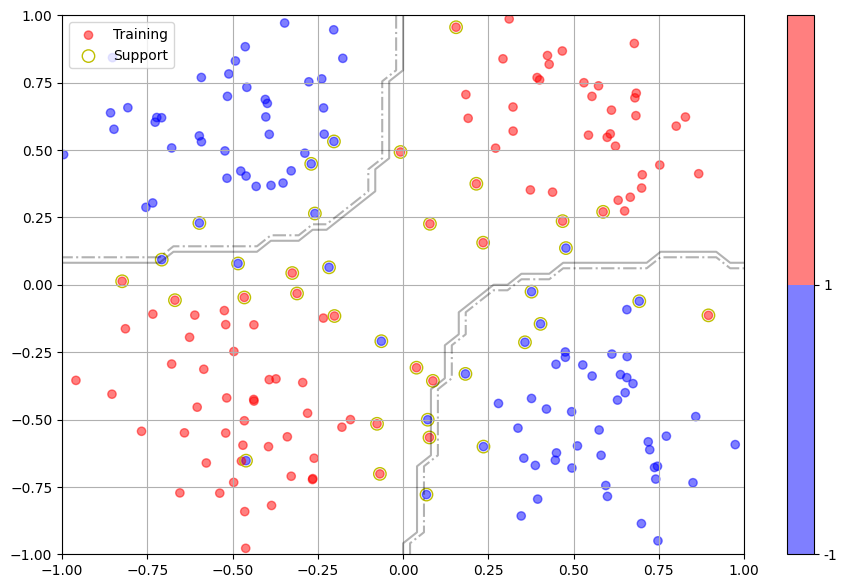

In [ ]:
fig, ax = plt.subplots(1, figsize=(11, 7))
plotSvm(xTrain, yTrain, support=model30.supportVectors, label='Training', ax=ax)

# Тооцоолол, шийдвэрийн хил хязгаар
xx = np.linspace(-1, 1, 50)
X0, X1 = np.meshgrid(xx, xx)
xy = np.vstack([X0.ravel(), X1.ravel()]).T
Y30 = model30.predict(xy).reshape(X0.shape)
ax.contour(X0, X1, Y30, colors='k', levels=[-1, 0], alpha=0.3, linestyles=['-.', '-']);

## Scikit Learn SVM with Radial basis kernel

In [ ]:
model31 = svm.SVC(kernel='rbf', C=10, gamma=1/2, shrinking=False)
model31.fit(xTrain, yTrain)

SVC(C=10, gamma=0.5, shrinking=False)

Number of support vectors = 41


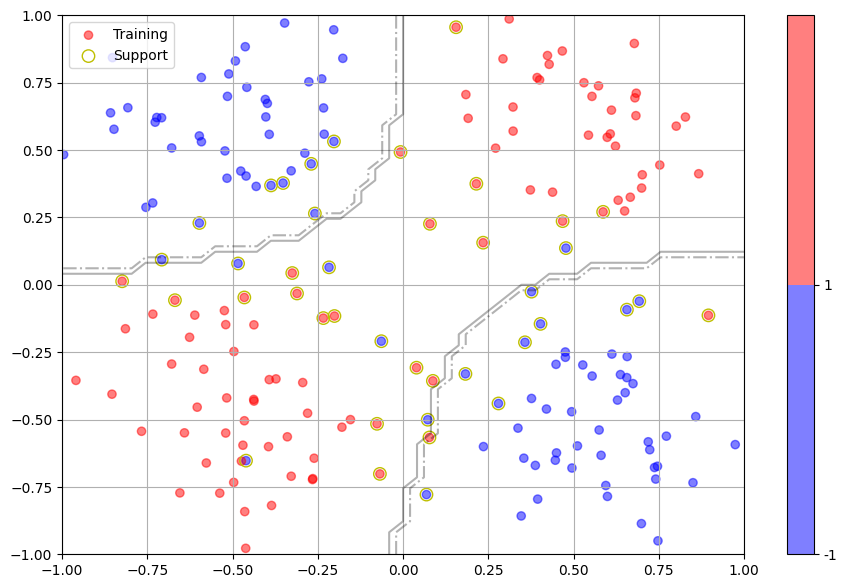

In [ ]:
fig, ax = plt.subplots(1, figsize=(11, 7))
plotSvm(xTrain, yTrain, support=model31.support_vectors_, label='Training', ax=ax)

# Тооцоолол, шийдвэрийн хил хязгаар
Y31 = model31.predict(xy).reshape(X0.shape)
ax.contour(X0, X1, Y31, colors='k', levels=[-1, 0], alpha=0.3, linestyles=['-.', '-']);

### SVM with RBF performance on XOR

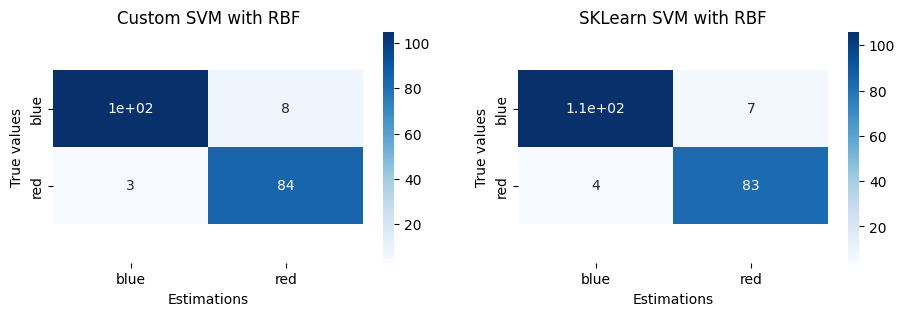

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
for model, ax, title in zip([model30, model31], axes, ["Custom SVM with RBF", "SKLearn SVM with RBF"]):
    yEst3 = model.predict(xTest)
    plotConfusionMatrix(yTest, yEst3, colors, title, ax=ax)

Хоёр загварын таамаглал XOR жишээн дээр бараг таарч байна.

# Даалгавар 3: Олон ангилалт SVM хэрэгжүүлэх алгоритмыг гүйцэтгэх

## Дүгнэлт

Шугаман салгах боломжгүй асуудлуудад зориулсан SVM ангилагчийн хүчийг бид харуулсан. 1990-ээд оны сүүлчээс эхлэн SVM нь олон асуудалд зориулсан машин сургалтын алгоритмын бүлийн тэргүүлэгч байсан. Энэ байдал 2010 оноос хойш бага зэрэг өөрчлөгдсөн бөгөөд гүнзгийрүүлсэн сургалт нь зарим ангиллын бодлогод илүү сайн гүйцэтгэлийг харуулсан. Гэсэн хэдий ч SVM нь олон нөхцөл байдалд илүү хүчтэй хэвээр байна. Жишээлбэл, SVM-д зориулсан сургалтын мэдээллийн хэмжээ нь гүнзгий суралцахад шаардагдах хэмжээнээс бага байна.

### Эндээс хаашаа явах вэ

- Multiclass classifier using Neural Nets in Keras ([HTML](ClassificationMulti2Features-Keras.html) / [Jupyter](ClassificationMulti2Features-Keras.ipynb))
- Multiclass classifier using Decision Trees ([HTML](ClassificationMulti2Features-Tree.html) / [Jupyter](ClassificationMulti2Features-Tree.ipynb))
- Bivariate continuous function approximation with Linear Regression ([HTML](ClassificationContinuous2Features.html) / [Jupyter](ClassificationContinuous2Features.ipynb))
- Bivariate continuous function approximation with k Nearest Neighbors ([HTML](ClassificationContinuous2Features-KNN.html) / [Jupyter](ClassificationContinuous2Features-KNN.ipynb))

# Даалгавар 3 — MNIST: олон ангилалттай Soft-margin SVM

MNIST-ийн 28 × 28 пикселтэй гар бичмэл цифрийг **0–9 гэсэн 10 ангид** ангилна.
Энэ хэсгийг дээрх жишээнүүдээс хамааралгүйгээр эхнээс нь дарааллаар ажиллуулж болно.
Шаардлагатай сан: `numpy`, `matplotlib`, `scikit-learn`.

## 1. Soft-margin ба One-vs-Rest

Soft-margin нь зарим дээж margin дотор орох эсвэл буруу ангилагдахыг зөвшөөрнө:

$$\min_{w,b,\xi}\frac12\|w\|^2+C\sum_{i=1}^{n}\xi_i,
\qquad y_i(w^Tx_i+b)\geq1-\xi_i,\quad\xi_i\geq0.$$

Доорх NumPy хэрэгжүүлэлт ижил төрлийн hinge-loss зорилгыг дундажлан ашиглана:

$$J_k=\frac{\lambda}{2}\|w_k\|^2+
\frac1n\sum_i\max(0,1-y_{ik}(w_k^Tx_i+b_k)).$$

Энд $y_{ik}=+1$ бол цифр $k$, бусад нь $-1$; $\lambda=1/(nC)$ үед дээрх
нийлбэртэй зорилгын масштабласан хэлбэр болно. Bias-ийг regularization-д оруулахгүй.

**One-vs-Rest (OvR):** 10 хоёртын SVM сургаад
$\hat y=\arg\max_k(w_k^Tx+b_k)$ гэж хамгийн их оноотой ангийг сонгоно.
Энэ нь softmax биш: оноонууд нь магадлал биш, hinge loss ашиглана.

In [1]:
%matplotlib inline
import time
from pathlib import Path
from urllib.request import urlretrieve
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

SEED = 42

## 2. MNIST өгөгдөл бэлтгэх

Эхний удаа Keras-ийн MNIST архивыг интернетээс `Data/mnist.npz` рүү татна;
дараагийн удаа хадгалсан файлыг ашиглана. Албан ёсны 60,000 сургалтын,
10,000 тестийн хуваалтыг хадгална. Пикселийг 255-д хувааж [0, 1] болгож,
зураг бүрийг 784 шинжтэй вектор болгон хувиргана.

Хурдан туршихын тулд сургалтын хэсгээс ангийн харьцааг хадгалсан 12,000 дээж,
тусдаа 3,000 validation дээж авна. Тестийн 10,000 дээжийг сургалт болон
параметр сонголтод ашиглахгүй.

Train: (12000, 784) Validation: (3000, 784) Test: (10000, 784)
Train class counts: [1185 1348 1192 1226 1168 1084 1184 1253 1170 1190]


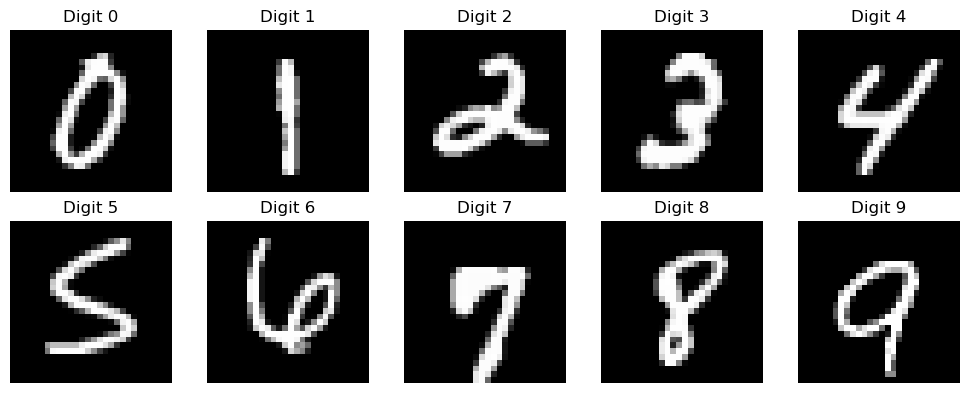

In [2]:
mnist_path = Path("Data/mnist.npz")
mnist_path.parent.mkdir(parents=True, exist_ok=True)
if not mnist_path.exists():
    urlretrieve("https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz", mnist_path)

with np.load(mnist_path, allow_pickle=False) as data:
    mnist_train_images = data["x_train"]
    mnist_train_labels = data["y_train"]
    mnist_test_images = data["x_test"]
    mnist_y_test = data["y_test"].astype(np.int64)

train_indices, val_indices = train_test_split(
    np.arange(len(mnist_train_labels)), train_size=12000, test_size=3000,
    stratify=mnist_train_labels, random_state=SEED,
)
mnist_X_train = mnist_train_images[train_indices].reshape(-1, 784).astype(np.float32) / 255.0
mnist_y_train = mnist_train_labels[train_indices].astype(np.int64)
mnist_X_val = mnist_train_images[val_indices].reshape(-1, 784).astype(np.float32) / 255.0
mnist_y_val = mnist_train_labels[val_indices].astype(np.int64)
mnist_X_test = mnist_test_images.reshape(-1, 784).astype(np.float32) / 255.0

print("Train:", mnist_X_train.shape, "Validation:", mnist_X_val.shape, "Test:", mnist_X_test.shape)
print("Train class counts:", np.bincount(mnist_y_train, minlength=10))
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit, ax in enumerate(axes.flat):
    index = np.flatnonzero(mnist_y_train == digit)[0]
    ax.imshow(mnist_X_train[index].reshape(28, 28), cmap="gray")
    ax.set_title(f"Digit {digit}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. NumPy-гаар Soft-margin OvR SVM бичих

Mini-batch бүр дээр 10 ангилагчийн жинг зэрэг шинэчилнэ.
$y_{ik}f_k(x_i)<1$ нөхцөлтэй дээжүүд hinge loss-ийн градиентэд орно:

$$\nabla_{w_k}J_k=\lambda w_k-\frac1B\sum_{i\in batch}y_{ik}x_i\,
\mathbf1[y_{ik}f_k(x_i)<1],$$
$$\nabla_{b_k}J_k=-\frac1B\sum_{i\in batch}y_{ik}\,
\mathbf1[y_{ik}f_k(x_i)<1].$$

Epoch бүр дээжүүдийг холино, сурах хурдыг аажмаар бууруулна.
Validation accuracy хамгийн өндөр байсан epoch-ийн жинг хадгална.

In [3]:
class SoftMarginOVRSVM:
    def __init__(self, reg=1e-4, learning_rate=0.1, epochs=50, batch_size=256, random_state=42):
        self.reg = reg
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state

    def fit(self, X, y, X_val, y_val):
        self.classes_ = np.unique(y)
        self.W_ = np.zeros((X.shape[1], len(self.classes_)), dtype=np.float32)
        self.b_ = np.zeros(len(self.classes_), dtype=np.float32)
        targets = np.where(y[:, None] == self.classes_[None, :], 1.0, -1.0).astype(np.float32)
        rng = np.random.default_rng(self.random_state)
        self.history_ = {"loss": [], "train_accuracy": [], "val_accuracy": []}
        best_accuracy = -np.inf

        for epoch in range(self.epochs):
            order = rng.permutation(len(X))
            eta = self.learning_rate / (1.0 + 0.1 * epoch)
            for start in range(0, len(X), self.batch_size):
                indices = order[start:start + self.batch_size]
                xb, yb = X[indices], targets[indices]
                scores = xb @ self.W_ + self.b_
                active = yb * scores < 1.0
                signed_active = yb * active
                grad_w = self.reg * self.W_ - xb.T @ signed_active / len(indices)
                grad_b = -signed_active.mean(axis=0)
                self.W_ -= eta * grad_w
                self.b_ -= eta * grad_b

            scores = self.decision_function(X)
            # Ангилагч тус бүрийн J_k-ийн нийлбэр.
            loss = (0.5 * self.reg * np.sum(self.W_ ** 2)
                    + np.maximum(0.0, 1.0 - targets * scores).sum(axis=1).mean())
            train_accuracy = accuracy_score(y, self.classes_[scores.argmax(axis=1)])
            val_accuracy = accuracy_score(y_val, self.predict(X_val))
            self.history_["loss"].append(float(loss))
            self.history_["train_accuracy"].append(train_accuracy)
            self.history_["val_accuracy"].append(val_accuracy)
            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                best_w, best_b = self.W_.copy(), self.b_.copy()
                self.best_epoch_ = epoch + 1
            if epoch == 0 or (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch + 1:2d}: loss={loss:.4f}, "
                      f"train={train_accuracy:.4f}, val={val_accuracy:.4f}")

        self.W_, self.b_ = best_w, best_b
        return self

    def decision_function(self, X):
        return X @ self.W_ + self.b_

    def predict(self, X):
        return self.classes_[self.decision_function(X).argmax(axis=1)]

Epoch  1: loss=1.1017, train=0.8512, val=0.8473


Epoch 10: loss=0.7000, train=0.8975, val=0.8930


Epoch 20: loss=0.6507, train=0.9022, val=0.8977


Epoch 30: loss=0.6298, train=0.9061, val=0.9010


Epoch 40: loss=0.6160, train=0.9080, val=0.9017


Epoch 50: loss=0.6071, train=0.9097, val=0.9030
Selected epoch: 42; training time: 0.77 s


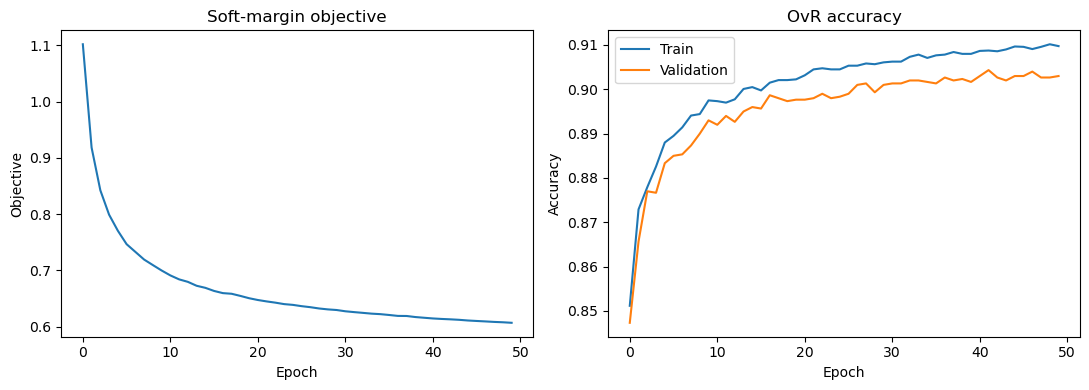

In [4]:
start = time.perf_counter()
mnist_custom = SoftMarginOVRSVM(random_state=SEED)
mnist_custom.fit(mnist_X_train, mnist_y_train, mnist_X_val, mnist_y_val)
custom_seconds = time.perf_counter() - start
print(f"Selected epoch: {mnist_custom.best_epoch_}; training time: {custom_seconds:.2f} s")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(mnist_custom.history_["loss"])
axes[0].set(xlabel="Epoch", ylabel="Objective", title="Soft-margin objective")
axes[1].plot(mnist_custom.history_["train_accuracy"], label="Train")
axes[1].plot(mnist_custom.history_["val_accuracy"], label="Validation")
axes[1].set(xlabel="Epoch", ylabel="Accuracy", title="OvR accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. sklearn-ийн Soft-margin SVM-тэй харьцуулах

`LinearSVC(loss="hinge", multi_class="ovr")` ашиглана.
C-ийн гурван утгыг зөвхөн validation дээр харьцуулж, хамгийн сайн загварыг сонгоно.
Хоёр хэрэгжүүлэлт ижил сургалтын дээж, ижил пикселийн масштаб ашиглана.
NumPy загвар mini-batch SGD, sklearn загвар өөр оновчлол болон bias-ийн
regularization ашигладаг тул үр дүн нь яг ижил байх шаардлагагүй.

Албан ёсны тайлбар: [LinearSVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html).

In [5]:
start = time.perf_counter()
mnist_sklearn = None
best_val_accuracy = -np.inf
for C in (0.01, 0.1, 1.0):
    candidate = LinearSVC(C=C, loss="hinge", multi_class="ovr", dual=True,
                          max_iter=100000, tol=1e-3, random_state=SEED)
    candidate.fit(mnist_X_train, mnist_y_train)
    val_accuracy = accuracy_score(mnist_y_val, candidate.predict(mnist_X_val))
    print(f"C={C}: validation accuracy={val_accuracy:.4f}")
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        mnist_sklearn = candidate
sklearn_seconds = time.perf_counter() - start
print(f"Selected C: {mnist_sklearn.C}; search time: {sklearn_seconds:.2f} s")

C=0.01: validation accuracy=0.9013


C=0.1: validation accuracy=0.9107


C=1.0: validation accuracy=0.9037
Selected C: 0.1; search time: 7.08 s


## 5. Тестийн үнэлгээ ба зургаар шалгах

Accuracy, macro-F1 болон анги бүрийн precision/recall/F1-ийг хэвлэнэ.
Confusion matrix-ийн мөр нь бодит цифр, багана нь таамагласан цифр.
Ногоон гарчигтай зураг зөв, улаан гарчигтай зураг буруу ангилагдсан байна.


NumPy Soft-margin OvR — test accuracy: 90.7700%
              precision    recall  f1-score   support

           0     0.9244    0.9857    0.9541       980
           1     0.9592    0.9736    0.9663      1135
           2     0.9231    0.8721    0.8969      1032
           3     0.9026    0.9079    0.9052      1010
           4     0.8890    0.9053    0.8971       982
           5     0.9113    0.8296    0.8685       892
           6     0.9212    0.9520    0.9363       958
           7     0.9124    0.9115    0.9119      1028
           8     0.8518    0.8614    0.8566       974
           9     0.8737    0.8642    0.8690      1009

    accuracy                         0.9077     10000
   macro avg     0.9069    0.9063    0.9062     10000
weighted avg     0.9076    0.9077    0.9073     10000


sklearn LinearSVC — test accuracy: 91.1600%
              precision    recall  f1-score   support

           0     0.9231    0.9796    0.9505       980
           1     0.9578    0.9797    0

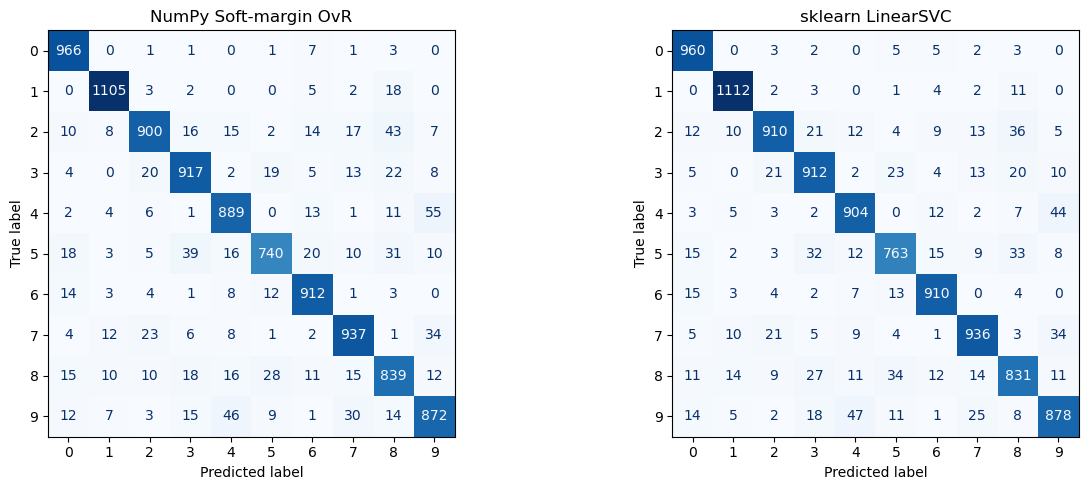

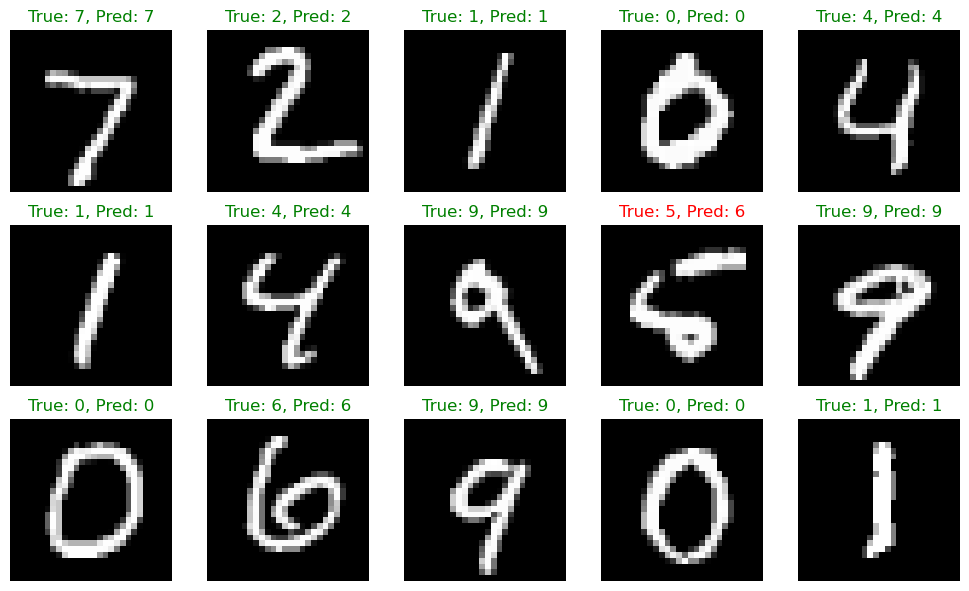

Custom SVM errors: 923 / 10000


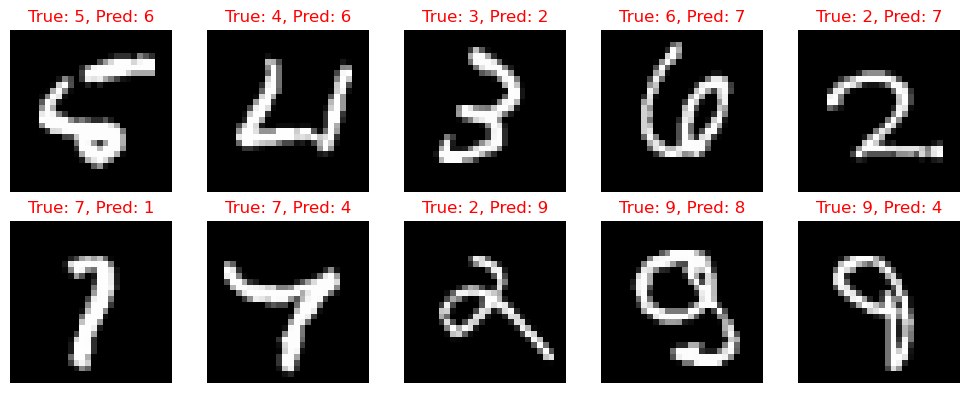

In [6]:
mnist_predictions = {}
for name, model in [("NumPy Soft-margin OvR", mnist_custom), ("sklearn LinearSVC", mnist_sklearn)]:
    predictions = model.predict(mnist_X_test)
    mnist_predictions[name] = predictions
    print(f"\n{name} — test accuracy: {accuracy_score(mnist_y_test, predictions):.4%}")
    print(classification_report(mnist_y_test, predictions, labels=np.arange(10), digits=4, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, predictions) in zip(axes, mnist_predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        mnist_y_test, predictions, labels=np.arange(10), ax=ax, cmap="Blues", colorbar=False,
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

custom_predictions = mnist_predictions["NumPy Soft-margin OvR"]
fig, axes = plt.subplots(3, 5, figsize=(10, 6))
for index, ax in enumerate(axes.flat):
    ax.imshow(mnist_X_test[index].reshape(28, 28), cmap="gray")
    correct = mnist_y_test[index] == custom_predictions[index]
    ax.set_title(f"True: {mnist_y_test[index]}, Pred: {custom_predictions[index]}",
                 color="green" if correct else "red")
    ax.axis("off")
plt.tight_layout()
plt.show()

wrong_indices = np.flatnonzero(mnist_y_test != custom_predictions)
print(f"Custom SVM errors: {len(wrong_indices)} / {len(mnist_y_test)}")
if len(wrong_indices):
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    for ax, index in zip(axes.flat, wrong_indices[:10]):
        ax.imshow(mnist_X_test[index].reshape(28, 28), cmap="gray")
        ax.set_title(f"True: {mnist_y_test[index]}, Pred: {custom_predictions[index]}", color="red")
    for ax in axes.flat:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## 6. Дүгнэлт

- Хоёртын SVM-ийг OvR аргаар 10 ангилалд өргөтгөв.
- Hinge loss ба L2 regularization нь soft-margin загварыг бүрдүүлнэ.
- Validation-аар NumPy загварын epoch, sklearn загварын C-г сонгож,
  тусдаа албан ёсны тестийн 10,000 зураг дээр үнэлэв.
- Дээр хэвлэгдсэн accuracy болон macro-F1-ээр хоёр загварыг харьцуулна.
  Confusion matrix болон алдаатай зургууд нь аль цифрүүд андуурагдаж байгааг харуулна.
- Энд шугаман SVM болон сургалтын 12,000 дээж ашигласан.
  Бүх сургалтын өгөгдөл эсвэл RBF kernel туршихад сургалтын хугацаа өснө.